# Fase 4 — Clasificador BiLSTM con Embeddings FastText

**Proyecto:** Grafo de conocimiento UAM-Azcapotzalco — Clasificación de tópicos de artículos científicos  
**Modelo:** BiLSTM bidireccional con embeddings FastText entrenados en la Fase 3  
**Entrenamiento:** arXiv Top-10 CS (corpus aumentado de la Fase 2)  
**Evaluación:** Validación interna arXiv (20%) + Transferencia pura sobre 733 artículos UAM-A  

---

## Celda 1 — Imports y Configuración

In [3]:
import torch, gensim, transformers, pandas, numpy

print(f"PyTorch     : {torch.__version__}")
print(f"CUDA        : {torch.version.cuda}")
print(f"GPU         : {torch.cuda.get_device_name(0)}")
print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"gensim      : {gensim.__version__}")
print(f"transformers: {transformers.__version__}")
print(f"pandas      : {pandas.__version__}")

PyTorch     : 2.11.0+cu128
CUDA        : 12.8
GPU         : NVIDIA GeForce RTX 5090
VRAM        : 34.2 GB
gensim      : 4.4.0
transformers: 5.4.0
pandas      : 2.3.3


In [4]:
# ─── Librerías estándar ───────────────────────────────────────────────────────
import os
import re
import json
import time
import random
import pickle
import warnings
from datetime import datetime
warnings.filterwarnings("ignore")


#  Ciencia de datos 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#  PyTorch 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

#  Scikit-learn 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

#  Utilidades 
from tqdm.notebook import tqdm

# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE DE CONFIGURACIÓN
# ─────────────────────────────────────────────────────────────────────────────

# Rutas de archivos
AUGMENTED_PATH  = r"D:\Aaron\arxiv_cs_top10_augmented.parquet"    #  Fase 2
EMBEDDING_PATH  = r"D:\Aaron\embedding_matrix_01_04_2026_09_39_20_.npy "               #  Fase 3
VOCAB_PATH      = r"D:\Aaron\vocab2idx_01_04_2026_09_39_20_.pkl"                      #  Fase 3
UAM_PATH        = r"C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset\Articulos.csv"              # dataset de transferencia

# --- Salidas ---
now = datetime.now() # Obtener la fecha y hora actual
date_time = now.strftime("%d_%m_%Y_%H_%M_%S")

MODEL_SAVE_PATH = r"D:\Aaron\Fase 4 BiLSTM\bilstm_best_"  + date_time + ".pt"                     # modelo a guardar

# Hiperparámetros
MAX_LEN       = 384    # tokens máximos por secuencia (truncado o padding)
BATCH_SIZE    = 64
HIDDEN_SIZE   = 256    # unidades LSTM por dirección
NUM_LAYERS    = 2      # capas LSTM apiladas
DROPOUT       = 0.3
LEARNING_RATE = 1e-3
EPOCHS        = 20
PATIENCE      = 5      # épocas sin mejora para early stopping
RANDOM_SEED   = 42
NUM_CLASSES   = 10
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ─── Fijar todas las semillas aleatorias ────────────────────────────────────
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False   # reproducibilidad > velocidad

set_seed(RANDOM_SEED)

print(f"Dispositivo de cómputo : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU                    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM total             : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch                : {torch.__version__}")

Dispositivo de cómputo : cuda
GPU                    : NVIDIA GeForce RTX 5090
VRAM total             : 34.2 GB
PyTorch                : 2.11.0+cu128


## Celda 2 — Carga de Artefactos de la Fase 3

In [5]:
#  Cargar embedding matrix 
print("Cargando embedding_matrix.npy ...")
embedding_matrix = np.load(EMBEDDING_PATH)          # shape: (147009, 300), float32

VOCAB_SIZE, EMBEDDING_DIM = embedding_matrix.shape
print(f"  → Forma de la matriz  : {embedding_matrix.shape}")
print(f"  → Tipo de dato        : {embedding_matrix.dtype}")
assert VOCAB_SIZE == 147_009, f"Vocabulario inesperado: {VOCAB_SIZE}"
assert EMBEDDING_DIM == 300,  f"Dimensión inesperada: {EMBEDDING_DIM}"
print("   Verificación de dimensiones correcta")

#  Cargar vocab2idx 
print("\nCargando vocab2idx.pkl ...")
with open(VOCAB_PATH, "rb") as f:
    vocab2idx = pickle.load(f)

print(f"  → Tokens en vocabulario : {len(vocab2idx):,}")
print(f"  → Índice <PAD>          : {vocab2idx.get('<PAD>', 0)}")
print(f"  → Índice <UNK>          : {vocab2idx.get('<UNK>', 1)}")

#  Verificar compatibilidad con nn.Embedding 
_test_emb = nn.Embedding.from_pretrained(
    torch.tensor(embedding_matrix[:10], dtype=torch.float32),
    freeze=False, padding_idx=0
)
del _test_emb

print("   Compatible con nn.Embedding.from_pretrained()")

def clean_and_tokenize(text: str) -> list[str]:
    """Limpieza y tokenización consistente con la Fase 3.
    
    Pasos:
      1. Minúsculas
      2. Eliminar referencias numéricas tipo [1], (2019)
      3. Eliminar caracteres no ASCII y puntuación, conservar hifens internos
      4. Colapsar espacios múltiples
      5. Split por espacios → lista de tokens (≥ 2 caracteres)
    """
    if not isinstance(text, str) or not text.strip():
        return []
    text = text.lower()
    text = re.sub(r"\[\d+\]|\(\d{4}\)", " ", text)  # referencias numéricas
    text = re.sub(r"[^a-z0-9\s\-]", " ", text)        # no-ASCII / puntuación
    text = re.sub(r"(?<![a-z])\-|\-(?![a-z])", " ", text)  # hifens no internos
    text = re.sub(r"\s+", " ", text).strip()
    return [t for t in text.split() if len(t) >= 2]

#  Conversión de texto → secuencia de índices con padding 
PAD_IDX = 0
UNK_IDX = 1

def text_to_sequence(text: str, max_len: int = MAX_LEN) -> list[int]:
    """Convierte texto a lista de enteros de longitud max_len.
    
    - Tokens en vocab  → su índice
    - Tokens <UNK>     → índice 1
    - Relleno (<PAD>)  → índice 0 (post-padding)
    - Truncado         → se conservan los primeros max_len tokens
    """
    tokens = clean_and_tokenize(text)
    indices = [vocab2idx.get(t, UNK_IDX) for t in tokens[:max_len]]
    # Post-padding hasta max_len
    indices += [PAD_IDX] * (max_len - len(indices))
    return indices

# Prueba rápida
_sample = "Deep learning methods have shown strong performance on image classification tasks."
_seq    = text_to_sequence(_sample)
assert len(_seq) == MAX_LEN, "La secuencia no tiene MAX_LEN elementos."
print(f"\n   text_to_sequence() verificada — longitud de salida: {len(_seq)}")

Cargando embedding_matrix.npy ...
  → Forma de la matriz  : (147009, 300)
  → Tipo de dato        : float32
   Verificación de dimensiones correcta

Cargando vocab2idx.pkl ...
  → Tokens en vocabulario : 147,009
  → Índice <PAD>          : 0
  → Índice <UNK>          : 1
   Compatible con nn.Embedding.from_pretrained()

   text_to_sequence() verificada — longitud de salida: 384


## Celda 3 — Carga y Preparación del Corpus arXiv

In [6]:
from tqdm.auto import tqdm
# Cargar corpus aumentado 
print(f"Cargando {AUGMENTED_PATH} ...")
df = pd.read_parquet(AUGMENTED_PATH)
print(f"  → Filas totales  : {len(df):,}")
print(f"  → Columnas       : {list(df.columns)}")

# Columna de texto: se asume 'texto_limpio'; ajustar si difiere
TEXT_COL  = "texto_limpio"
LABEL_COL = "cs_primary"

assert TEXT_COL  in df.columns, f"Columna '{TEXT_COL}' no encontrada"
assert LABEL_COL in df.columns, f"Columna '{LABEL_COL}' no encontrada"

# Eliminar nulos
df = df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)
print(f"  → Tras eliminar nulos : {len(df):,}")

#  Mapeo de etiquetas 
LABEL_ORDER = sorted(df[LABEL_COL].unique().tolist())  # orden alfabético estable
label2idx   = {lbl: idx for idx, lbl in enumerate(LABEL_ORDER)}
idx2label   = {idx: lbl for lbl, idx in label2idx.items()}

print(f"\nClases ({len(label2idx)}) y sus índices:")
for lbl, idx in label2idx.items():
    print(f"  {idx:2d}  {lbl}")

#  Pesos de clase: peso_i = N_total / (K × N_i) 
N_total = len(df)
K       = len(label2idx)
class_counts  = df[LABEL_COL].value_counts()
class_weights = torch.tensor(
    [N_total / (K * class_counts[lbl]) for lbl in LABEL_ORDER],
    dtype=torch.float32
)
print("\nPesos de clase (para CrossEntropyLoss):")
for lbl, w in zip(LABEL_ORDER, class_weights.tolist()):
    print(f"  {lbl:8s}  {w:.4f}   (N={class_counts[lbl]:,})")

#  Tokenización y conversión a secuencias 
print("\nTokenizando y convirtiendo abstracts a secuencias de índices...")
# Calcular longitudes ANTES del truncado para estadísticas
raw_lengths = df[TEXT_COL].apply(
    lambda t: len(clean_and_tokenize(t)) if isinstance(t, str) else 0
)
print(f"  Longitud promedio : {raw_lengths.mean():.1f} tokens")
print(f"  Longitud mínima   : {raw_lengths.min()} tokens")
print(f"  Longitud máxima   : {raw_lengths.max()} tokens")
print(f"  Percentil 95      : {raw_lengths.quantile(0.95):.0f} tokens")
print(f"  Cobertura MAX_LEN : {(raw_lengths <= MAX_LEN).mean()*100:.1f}% de secuencias caben sin truncado")

sequences = [
    text_to_sequence(text)
    for text in tqdm(df[TEXT_COL], desc="Convirtiendo a índices")
]
labels = [label2idx[lbl] for lbl in df[LABEL_COL]]

print(f"\n   {len(sequences):,} secuencias listas")

Cargando D:\Aaron\arxiv_cs_top10_augmented.parquet ...
  → Filas totales  : 713,063
  → Columnas       : ['title', 'abstract', 'cs_primary', 'texto_limpio', 'aug_method', 'id']
  → Tras eliminar nulos : 713,063

Clases (10) y sus índices:
   0  cs.AI
   1  cs.CL
   2  cs.CR
   3  cs.CV
   4  cs.DS
   5  cs.IT
   6  cs.LG
   7  cs.NA
   8  cs.RO
   9  cs.SY

Pesos de clase (para CrossEntropyLoss):
  cs.AI     1.4634   (N=48,726)
  cs.CL     0.8840   (N=80,661)
  cs.CR     1.5647   (N=45,571)
  cs.CV     0.4494   (N=158,664)
  cs.DS     1.8266   (N=39,038)
  cs.IT     1.4581   (N=48,902)
  cs.LG     0.4361   (N=163,511)
  cs.NA     1.7811   (N=40,034)
  cs.RO     1.5353   (N=46,445)
  cs.SY     1.7178   (N=41,511)

Tokenizando y convirtiendo abstracts a secuencias de índices...
  Longitud promedio : 157.8 tokens
  Longitud mínima   : 0 tokens
  Longitud máxima   : 563 tokens
  Percentil 95      : 240 tokens
  Cobertura MAX_LEN : 100.0% de secuencias caben sin truncado


Convirtiendo a índices:   0%|          | 0/713063 [00:00<?, ?it/s]


   713,063 secuencias listas


## Celda 4 — Dataset y DataLoaders

In [7]:
class ArxivDataset(Dataset):
    """Dataset para secuencias de índices de tokens y etiquetas enteras."""

    def __init__(self, seqs: list[list[int]], labels: list[int]):
        # Convertir directamente a tensores para evitar copia por lote
        self.X = torch.tensor(seqs,   dtype=torch.long).clone()
        self.y = torch.tensor(labels, dtype=torch.long).clone()

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

# Convertir a numpy arrays para train_test_split
sequences_arr = np.array(sequences, dtype=object)
labels_arr    = np.array(labels,    dtype=np.int32)

# Split 70 / 15 / 15 estratificado
# Paso 1: separar train (70%) del resto (30%)
seq_train, seq_temp, lbl_train, lbl_temp = train_test_split(
    sequences_arr, labels_arr,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=labels_arr
)

# Paso 2: dividir el 30% restante en val (15%) y test (15%)
# test_size=0.5 porque 0.5 × 30% = 15% del total
seq_val, seq_test, lbl_val, lbl_test = train_test_split(
    seq_temp, lbl_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=lbl_temp
)

print(f"Partición del corpus:")
print(f"  Train      : {len(seq_train):,} muestras  (~70%)")
print(f"  Validación : {len(seq_val):,} muestras  (~15%)")
print(f"  Test       : {len(seq_test):,} muestras  (~15%)")

train_ds = ArxivDataset(seq_train.tolist(), lbl_train.tolist())
val_ds   = ArxivDataset(seq_val.tolist(),   lbl_val.tolist())
test_ds  = ArxivDataset(seq_test.tolist(),  lbl_test.tolist())

# DataLoaders 
# num_workers=0 en Windows para evitar errores de multiprocessing
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=(DEVICE.type == "cuda"),
    num_workers=0
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=(DEVICE.type == "cuda"),
    num_workers=0
)
test_loader  = DataLoader(
    test_ds,  
    batch_size=BATCH_SIZE, 
    shuffle=False,   
    pin_memory=(DEVICE.type == "cuda"), 
    num_workers=0
)



print(f"\nDataLoaders creados:")
print(f"  Lotes train      : {len(train_loader):,}")
print(f"  Lotes validación : {len(val_loader):,}")
print(f"  Lotes test       : {len(test_loader):,}")
print(f"  pin_memory       : {DEVICE.type == 'cuda'}")

Partición del corpus:
  Train      : 499,144 muestras  (~70%)
  Validación : 106,959 muestras  (~15%)
  Test       : 106,960 muestras  (~15%)

DataLoaders creados:
  Lotes train      : 7,800
  Lotes validación : 1,672
  Lotes test       : 1,672
  pin_memory       : True


## Celda 5 — Arquitectura BiLSTM

In [8]:
class BiLSTMClassifier(nn.Module):
    """Clasificador BiLSTM con embeddings FastText pre-entrenados.

    Arquitectura:
      Embedding (300d, fine-tunable) → Dropout → BiLSTM (2 capas) 
      → Pooling estados finales (fw + bw) → LayerNorm → Linear (10 clases)
    """

    def __init__(
        self,
        embedding_matrix: np.ndarray,
        hidden_size: int = HIDDEN_SIZE,
        num_layers: int  = NUM_LAYERS,
        num_classes: int = NUM_CLASSES,
        dropout: float   = DROPOUT,
        padding_idx: int = PAD_IDX
    ):
        super().__init__()
        vocab_size, emb_dim = embedding_matrix.shape

        #  Capa de embedding 
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),  # copia real, sin vínculo numpy
            freeze=False,
            padding_idx=padding_idx
        )

        #  Dropout post-embedding 
        self.emb_dropout = nn.Dropout(p=dropout)

        #  BiLSTM 
        # dropout interno de LSTM solo actúa ENTRE capas (num_layers > 1)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Normalización sobre representación concatenada 
        # El estado final concatena forward[-1] + backward[-1] → hidden_size * 2
        self.layer_norm = nn.LayerNorm(hidden_size * 2)

        #  Dropout pre-clasificación 
        self.cls_dropout = nn.Dropout(p=dropout)

        #  Capa de clasificación final 
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: LongTensor de forma (batch, seq_len) con índices de tokens
        Returns:
            logits: FloatTensor de forma (batch, num_classes)
        """
        # (batch, seq_len) → (batch, seq_len, emb_dim)
        emb = self.emb_dropout(self.embedding(x))

        # LSTM: output (batch, seq, hidden*2), hidden (num_layers*2, batch, hidden)
        _, (hidden, _) = self.lstm(emb)

        # hidden shape: (num_layers * 2, batch, hidden_size)
        # Extraer estados finales de la última capa: forward → [-2], backward → [-1]
        # Concatenar a lo largo de la dimensión oculta
        last_forward  = hidden[-2]   # (batch, hidden_size)
        last_backward = hidden[-1]   # (batch, hidden_size)
        pooled = torch.cat([last_forward, last_backward], dim=1)  # (batch, hidden*2)

        # Normalización + dropout
        pooled = self.layer_norm(pooled)
        pooled = self.cls_dropout(pooled)

        # Logits
        return self.classifier(pooled)  # (batch, num_classes)


model = BiLSTMClassifier(
    embedding_matrix=embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Arquitectura BiLSTM:")
print(model)
print(f"\nParámetros totales     : {total_params:,}")
print(f"Parámetros entrenables : {trainable_params:,}")

# Prueba de forward pass con lote sintético
with torch.no_grad():
    _x_dummy = torch.zeros(2, MAX_LEN, dtype=torch.long).to(DEVICE)
    _out     = model(_x_dummy)
    assert _out.shape == (2, NUM_CLASSES), f"Forma inesperada: {_out.shape}"
print("\n   Forward pass verificado — salida: (batch=2, num_classes=10)")

Arquitectura BiLSTM:
BiLSTMClassifier(
  (embedding): Embedding(147009, 300, padding_idx=0)
  (emb_dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (cls_dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=512, out_features=10, bias=True)
)

Parámetros totales     : 46,828,598
Parámetros entrenables : 46,828,598

   Forward pass verificado — salida: (batch=2, num_classes=10)


## Celda 6 — Configuración del Entrenamiento

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

#  Función de pérdida con pesos de clase 
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE)
)

#  Scheduler: reducir LR si Macro F1 de val no mejora 
# mode='max' porque optimizamos F1 (mayor = mejor)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5
)

#  GradScaler para mixed precision (AMP) 
scaler = GradScaler("cuda", enabled=(DEVICE.type == "cuda"))


#  Estado de early stopping 
best_val_f1    = -1.0
epochs_no_imp  = 0       # épocas consecutivas sin mejora
best_epoch     = 0

#  Historial de métricas 
history = {
    "train_loss" : [],
    "val_loss"   : [],
    "val_f1"     : [],
    "lr"         : []
}

print("Configuración del entrenamiento:")
print(f"  Optimizador  : Adam  (lr={LEARNING_RATE})")
print(f"  Pérdida      : CrossEntropyLoss con pesos de clase")
print(f"  Scheduler    : ReduceLROnPlateau (mode=max, patience=2, factor=0.5)")
print(f"  Mixed prec.  : {'Habilitada (AMP)' if DEVICE.type == 'cuda' else 'Deshabilitada (CPU)'}")
print(f"  Early stop.  : patience={PATIENCE} épocas (basado en Macro F1 val)")

Configuración del entrenamiento:
  Optimizador  : Adam  (lr=0.001)
  Pérdida      : CrossEntropyLoss con pesos de clase
  Scheduler    : ReduceLROnPlateau (mode=max, patience=2, factor=0.5)
  Mixed prec.  : Habilitada (AMP)
  Early stop.  : patience=5 épocas (basado en Macro F1 val)


## Celda 7 — Optuna


Configuración Optuna:
  Trials          : 15
  Épocas/trial    : 5
  Patience/trial  : 3
  Modelo output   : D:\Aaron\Fase 4 BiLSTM\optuna\bilstm_optuna_best_02_04_2026_14_08_04.pt
  Resultados      : D:\Aaron\Fase 4 BiLSTM\optuna\optuna_results_02_04_2026_14_08_04.json

Iniciando búsqueda Optuna — 15 trials máx.


  0%|          | 0/15 [00:00<?, ?it/s]

  Val  :   0%|          | 0/1672 [00:00<?, ?it/s]

  Val  :   0%|          | 0/1672 [00:00<?, ?it/s]

  Val  :   0%|          | 0/1672 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/1672 [00:00<?, ?it/s]

  Val  :   0%|          | 0/1672 [00:00<?, ?it/s]

  Val  :   0%|          | 0/1672 [00:00<?, ?it/s]

  Val  :   0%|          | 0/1672 [00:00<?, ?it/s]


Mejor Macro F1 (val)  : 0.8266
Mejor manual          : 0.8215
Diferencia            : +0.0051

Mejores hiperparámetros:
  lr              : 0.0007309539835912913
  dropout         : 0.30000000000000004
  batch_size      : 64
  hidden_size     : 512
  num_layers      : 1

  Trials completados : 5
  Trials podados     : 10

   D:\Aaron\Fase 4 BiLSTM\optuna\optuna_results_02_04_2026_14_08_04.json


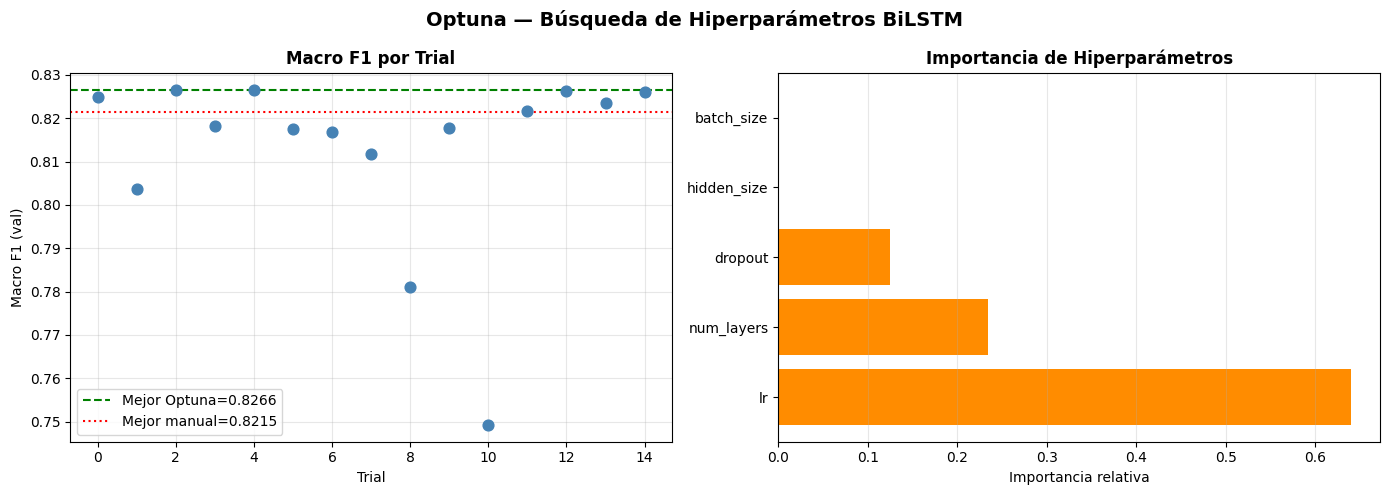

   D:\Aaron\Fase 4 BiLSTM\optuna\optuna_search_02_04_2026_14_08_04.png

Reentrenando modelo final con mejores hiperparámetros ...


NameError: name 'train_one_epoch' is not defined

In [11]:
import optuna
from optuna.samplers import TPESampler
from datetime import datetime
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN
# ─────────────────────────────────────────────────────────────────────────────
now       = datetime.now()
date_time = now.strftime("%d_%m_%Y_%H_%M_%S")

# Rutas de salida
OUTPUT_DIR             = r"D:\Aaron\Fase 4 BiLSTM\optuna"
OPTUNA_MODEL_SAVE_PATH = f"{OUTPUT_DIR}\\bilstm_optuna_best_{date_time}.pt"
OPTUNA_RESULTS_PATH    = f"{OUTPUT_DIR}\\optuna_results_{date_time}.json"
OPTUNA_PLOT_PATH       = f"{OUTPUT_DIR}\\optuna_search_{date_time}.png"

# Configuración del estudio
N_TRIALS          = 15
MAX_EPOCHS_OPTUNA = 5
PATIENCE_OPTUNA   = 3
N_STARTUP_TRIALS  = 3   # trials aleatorios antes de activar TPE
N_WARMUP_STEPS    = 2   # épocas antes de activar pruning

# Espacios de búsqueda
LR_MIN          = 1e-4
LR_MAX          = 1e-2
DROPOUT_MIN     = 0.2
DROPOUT_MAX     = 0.6
DROPOUT_STEP    = 0.1
BATCH_SIZES     = [64, 128, 256]
HIDDEN_SIZES    = [128, 256, 512]
NUM_LAYERS_MIN  = 1
NUM_LAYERS_MAX  = 3

# mejor resultado manual
BEST_MANUAL_F1  = 0.8215

print(f"Configuración Optuna:")
print(f"  Trials          : {N_TRIALS}")
print(f"  Épocas/trial    : {MAX_EPOCHS_OPTUNA}")
print(f"  Patience/trial  : {PATIENCE_OPTUNA}")
print(f"  Modelo output   : {OPTUNA_MODEL_SAVE_PATH}")
print(f"  Resultados      : {OPTUNA_RESULTS_PATH}")

# ─────────────────────────────────────────────────────────────────────────────
# FUNCIÓN OBJETIVO
# ─────────────────────────────────────────────────────────────────────────────
def objective(trial):
    lr          = trial.suggest_float("lr",          LR_MIN, LR_MAX, log=True)
    dropout     = trial.suggest_float("dropout",     DROPOUT_MIN, DROPOUT_MAX, step=DROPOUT_STEP)
    batch_size  = trial.suggest_categorical("batch_size",  BATCH_SIZES)
    hidden_size = trial.suggest_categorical("hidden_size", HIDDEN_SIZES)
    num_layers  = trial.suggest_int("num_layers", NUM_LAYERS_MIN, NUM_LAYERS_MAX)

    set_seed(RANDOM_SEED)
    _model = BiLSTMClassifier(
        embedding_matrix=embedding_matrix,
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_classes=NUM_CLASSES,
        dropout=dropout
    ).to(DEVICE)

    _optimizer = torch.optim.Adam(_model.parameters(), lr=lr)
    _criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    _scaler    = GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

    _train_loader = DataLoader(
        train_ds, batch_size=batch_size,
        shuffle=True, pin_memory=(DEVICE.type == "cuda"), num_workers=0
    )
    _val_loader = DataLoader(
        val_ds, batch_size=batch_size,
        shuffle=False, pin_memory=(DEVICE.type == "cuda"), num_workers=0
    )

    best_f1       = -1.0
    epochs_no_imp = 0

    for epoch in range(1, MAX_EPOCHS_OPTUNA + 1):
        _model.train()
        for X_b, y_b in _train_loader:
            X_b = X_b.to(DEVICE, non_blocking=True)
            y_b = y_b.to(DEVICE, non_blocking=True)
            _optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=(DEVICE.type == "cuda")):
                loss = _criterion(_model(X_b), y_b)
            _scaler.scale(loss).backward()
            _scaler.unscale_(_optimizer)
            nn.utils.clip_grad_norm_(_model.parameters(), max_norm=1.0)
            _scaler.step(_optimizer)
            _scaler.update()

        _, val_f1, _, _ = evaluate(_model, _val_loader, _criterion, DEVICE)

        trial.report(val_f1, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if val_f1 > best_f1:
            best_f1       = val_f1
            epochs_no_imp = 0
        else:
            epochs_no_imp += 1
            if epochs_no_imp >= PATIENCE_OPTUNA:
                break

    del _model, _optimizer, _scaler
    torch.cuda.empty_cache()

    return best_f1
    
def evaluate(model, loader, criterion, device):
    """Evaluación sobre un loader; retorna (loss, macro_f1, predicciones, etiquetas)."""
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in tqdm(loader, desc="  Val  ", leave=False):
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            preds  = torch.argmax(logits, dim=1)

            total_loss += loss.item() * len(y_batch)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, macro_f1, all_preds, all_labels
# ─────────────────────────────────────────────────────────────────────────────
# EJECUTAR ESTUDIO
# ─────────────────────────────────────────────────────────────────────────────
sampler = TPESampler(seed=RANDOM_SEED)
pruner  = optuna.pruners.MedianPruner(
    n_startup_trials=N_STARTUP_TRIALS,
    n_warmup_steps=N_WARMUP_STEPS
)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
    study_name="bilstm_phase4"
)

print(f"\nIniciando búsqueda Optuna — {N_TRIALS} trials máx.")
print("=" * 60)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

# ─────────────────────────────────────────────────────────────────────────────
# RESULTADOS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"Mejor Macro F1 (val)  : {study.best_value:.4f}")
print(f"Mejor manual          : {BEST_MANUAL_F1:.4f}")
print(f"Diferencia            : {study.best_value - BEST_MANUAL_F1:+.4f}")
print(f"\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k:<15} : {v}")

n_pruned    = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
n_completed = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
print(f"\n  Trials completados : {n_completed}")
print(f"  Trials podados     : {n_pruned}")

# ─────────────────────────────────────────────────────────────────────────────
# GUARDAR RESULTADOS
# ─────────────────────────────────────────────────────────────────────────────
optuna_results = {
    "timestamp"    : date_time,
    "best_val_f1"  : round(study.best_value, 6),
    "best_manual_f1" : BEST_MANUAL_F1,
    "delta"        : round(study.best_value - BEST_MANUAL_F1, 6),
    "best_params"  : study.best_params,
    "search_space" : {
        "lr"          : [LR_MIN, LR_MAX],
        "dropout"     : [DROPOUT_MIN, DROPOUT_MAX],
        "batch_sizes" : BATCH_SIZES,
        "hidden_sizes": HIDDEN_SIZES,
        "num_layers"  : [NUM_LAYERS_MIN, NUM_LAYERS_MAX]
    },
    "n_trials"     : len(study.trials),
    "n_completed"  : n_completed,
    "n_pruned"     : n_pruned
}
with open(OPTUNA_RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(optuna_results, f, indent=2)
print(f"\n   {OPTUNA_RESULTS_PATH}")

# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Historial de trials
completed_trials = [t for t in study.trials if t.value is not None]
trial_nums = [t.number for t in completed_trials]
trial_f1s  = [t.value  for t in completed_trials]

axes[0].scatter(trial_nums, trial_f1s, c="steelblue", s=60, zorder=3)
axes[0].axhline(study.best_value, color="green", linestyle="--",
                label=f"Mejor Optuna={study.best_value:.4f}")
axes[0].axhline(BEST_MANUAL_F1,   color="red",   linestyle=":",
                label=f"Mejor manual={BEST_MANUAL_F1:.4f}")
axes[0].set_title("Macro F1 por Trial", fontweight="bold")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Macro F1 (val)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Importancia de hiperparámetros
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()), color="darkorange")
axes[1].set_title("Importancia de Hiperparámetros", fontweight="bold")
axes[1].set_xlabel("Importancia relativa")
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Optuna — Búsqueda de Hiperparámetros BiLSTM", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OPTUNA_PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"   {OPTUNA_PLOT_PATH}")



In [12]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    """Ejecuta una época de entrenamiento con AMP."""
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in tqdm(loader, desc="  Train", leave=False):
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)  # más eficiente que zero_grad()

        with autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * len(y_batch)

    return total_loss / len(loader.dataset)

# ─────────────────────────────────────────────────────────────────────────────
# REENTRENAR CON MEJORES HIPERPARÁMETROS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Reentrenando modelo final con mejores hiperparámetros ...")
print("=" * 60)

best = study.best_params
set_seed(RANDOM_SEED)

model_optuna = BiLSTMClassifier(
    embedding_matrix=embedding_matrix,
    hidden_size=best["hidden_size"],
    num_layers=best["num_layers"],
    num_classes=NUM_CLASSES,
    dropout=best["dropout"]
).to(DEVICE)

optimizer_optuna = torch.optim.Adam(model_optuna.parameters(), lr=best["lr"])
criterion_optuna = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
scaler_optuna    = GradScaler("cuda", enabled=(DEVICE.type == "cuda"))
scheduler_optuna = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_optuna, mode="max", patience=2, factor=0.5
)

train_loader_optuna = DataLoader(
    train_ds, batch_size=best["batch_size"],
    shuffle=True, pin_memory=(DEVICE.type == "cuda"), num_workers=0
)
val_loader_optuna = DataLoader(
    val_ds, batch_size=best["batch_size"],
    shuffle=False, pin_memory=(DEVICE.type == "cuda"), num_workers=0
)

best_val_f1_optuna = -1.0
epochs_no_imp_optuna = 0
best_epoch_optuna    = 0
history_optuna = {"train_loss": [], "val_loss": [], "val_f1": []}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss = train_one_epoch(
        model_optuna, train_loader_optuna,
        optimizer_optuna, criterion_optuna, scaler_optuna, DEVICE
    )
    val_loss, val_f1, _, _ = evaluate(
        model_optuna, val_loader_optuna, criterion_optuna, DEVICE
    )
    history_optuna["train_loss"].append(train_loss)
    history_optuna["val_loss"].append(val_loss)
    history_optuna["val_f1"].append(val_f1)

    print(
        f"Época {epoch:02d}/{EPOCHS}  "
        f"| train_loss={train_loss:.4f}  "
        f"| val_loss={val_loss:.4f}  "
        f"| val_macro_f1={val_f1:.4f}  "
        f"| {time.time()-t0:.0f}s"
    )

    if val_f1 > best_val_f1_optuna:
        best_val_f1_optuna   = val_f1
        best_epoch_optuna    = epoch
        epochs_no_imp_optuna = 0
        torch.save(model_optuna.state_dict(), OPTUNA_MODEL_SAVE_PATH)
        print(f"           Guardado (Macro F1={best_val_f1_optuna:.4f})")
    else:
        epochs_no_imp_optuna += 1
        print(f"          – Sin mejora ({epochs_no_imp_optuna}/{PATIENCE})")

    scheduler_optuna.step(val_f1)

    if epochs_no_imp_optuna >= PATIENCE:
        print(f"\n  Early stopping en época {epoch} (mejor: {best_epoch_optuna})")
        break

print("=" * 60)
print(f"Mejor val F1 (Optuna) : {best_val_f1_optuna:.4f}")
print(f"Mejor manual          : {BEST_MANUAL_F1:.4f}")
print(f"Diferencia            : {best_val_f1_optuna - BEST_MANUAL_F1:+.4f}")
print(f"   Modelo guardado: {OPTUNA_MODEL_SAVE_PATH}")



Reentrenando modelo final con mejores hiperparámetros ...


  Train:   0%|          | 0/7800 [00:00<?, ?it/s]

  Val  :   0%|          | 0/1672 [00:00<?, ?it/s]

Época 01/20  | train_loss=0.6158  | val_loss=0.4956  | val_macro_f1=0.8174  | 505s
           Guardado (Macro F1=0.8174)


  Train:   0%|          | 0/7800 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/1672 [00:00<?, ?it/s]

Época 06/20  | train_loss=0.1583  | val_loss=0.7160  | val_macro_f1=0.8114  | 505s
          – Sin mejora (4/5)


  Train:   0%|          | 0/7800 [00:00<?, ?it/s]

  Val  :   0%|          | 0/1672 [00:00<?, ?it/s]

Época 07/20  | train_loss=0.1303  | val_loss=0.8476  | val_macro_f1=0.8075  | 501s
          – Sin mejora (5/5)

  Early stopping en época 7 (mejor: 2)
Mejor val F1 (Optuna) : 0.8238
Mejor manual          : 0.8215
Diferencia            : +0.0023
   Modelo guardado: D:\Aaron\Fase 4 BiLSTM\optuna\bilstm_optuna_best_02_04_2026_14_08_04.pt


In [13]:
import requests
requests.post(
    "https://ntfy.sh/aaron-ml-experiments", 
    data="Entrenamiento Optuna Terminado",
    headers={"Title": "ML Pipeline", "Priority": "high"}
)


<Response [200]>

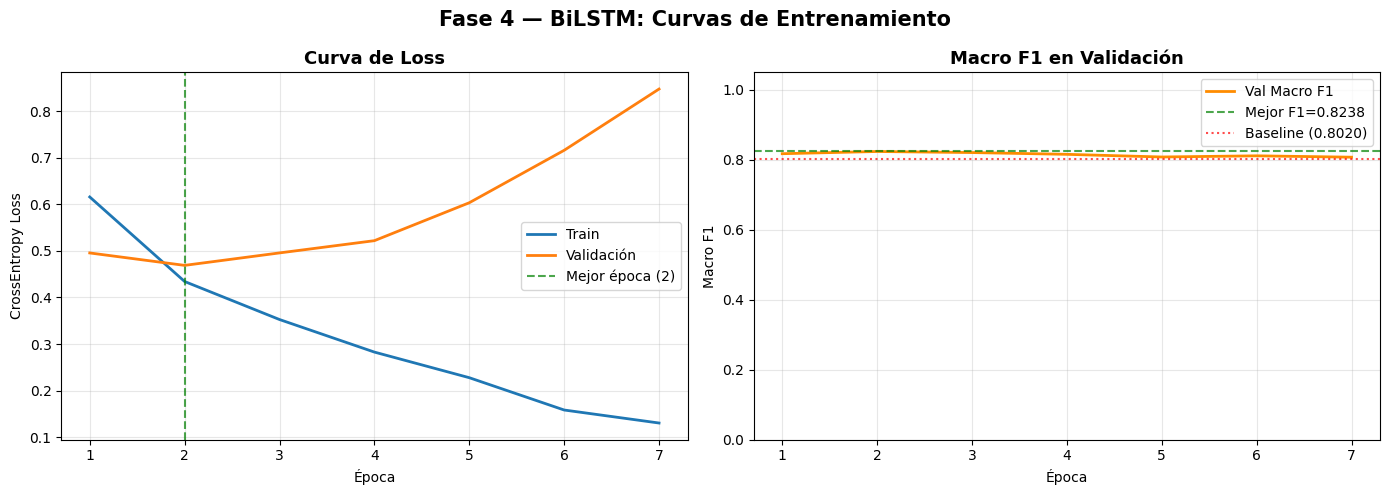

   Gráfica guardada: bilstm_training_curves.png


In [19]:
#  Curvas de aprendizaje 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history_optuna["train_loss"]) + 1)

# Loss
axes[0].plot(epochs_range, history_optuna["train_loss"], label="Train",      linewidth=2)
axes[0].plot(epochs_range, history_optuna["val_loss"],   label="Validación", linewidth=2)
axes[0].axvline(best_epoch_optuna, color="green", linestyle="--", alpha=0.7, label=f"Mejor época ({best_epoch_optuna})")
axes[0].set_title("Curva de Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Macro F1
axes[1].plot(epochs_range, history_optuna["val_f1"], color="darkorange", linewidth=2, label="Val Macro F1")
axes[1].axhline(best_val_f1_optuna, color="green", linestyle="--", alpha=0.7, label=f"Mejor F1={best_val_f1_optuna:.4f}")
axes[1].axhline(0.8020,       color="red",   linestyle=":",  alpha=0.7, label="Baseline (0.8020)")
axes[1].set_title("Macro F1 en Validación", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Macro F1")
axes[1].set_ylim(0.0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Fase 4 — BiLSTM: Curvas de Entrenamiento", fontsize=15, fontweight="bold")
plt.tight_layout()
#plt.savefig("bilstm_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("   Gráfica guardada: bilstm_training_curves.png")

  Val  :   0%|          | 0/1672 [00:00<?, ?it/s]

  EVALUACIÓN — TEST INTERNO arXiv (15%) — OPTUNA
  Test Loss  : 0.4694
  Macro F1   : 0.8248

              precision    recall  f1-score   support

       cs.AI     0.6092    0.4890    0.5425      7309
       cs.CL     0.8520    0.8704    0.8611     12099
       cs.CR     0.7787    0.9358    0.8500      6835
       cs.CV     0.8932    0.8968    0.8950     23800
       cs.DS     0.9211    0.8728    0.8963      5856
       cs.IT     0.8610    0.8984    0.8793      7336
       cs.LG     0.8260    0.7525    0.7875     24527
       cs.NA     0.8168    0.9312    0.8703      6005
       cs.RO     0.8179    0.8954    0.8549      6967
       cs.SY     0.7886    0.8358    0.8115      6226

    accuracy                         0.8325    106960
   macro avg     0.8164    0.8378    0.8248    106960
weighted avg     0.8304    0.8325    0.8297    106960



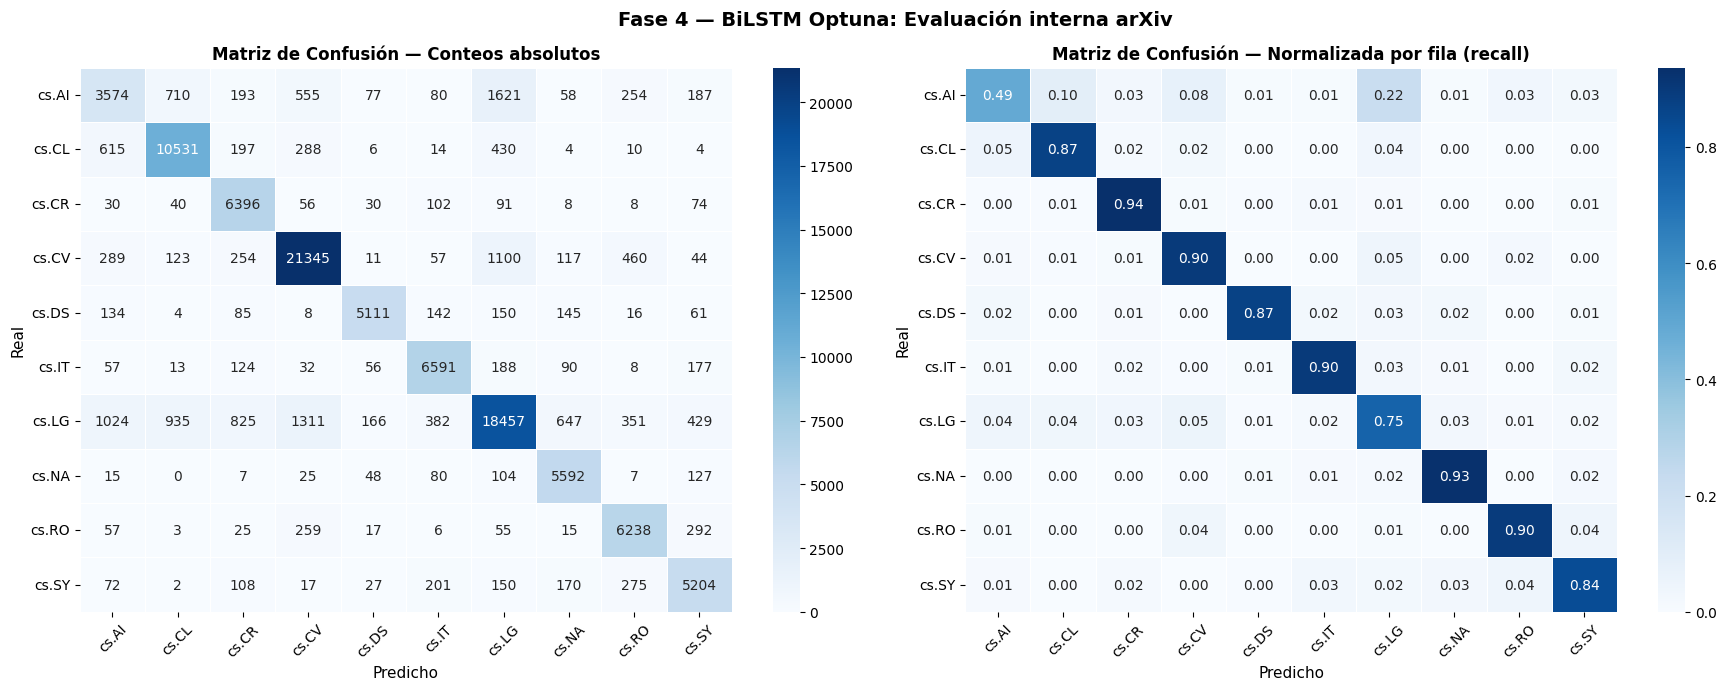

──────────────────────────────────────────────────
  Modelo                           Macro F1
──────────────────────────────────────────────────
  TF-IDF + LogReg (baseline)         0.8020
  BiLSTM manual                      0.8215
  BiLSTM Optuna                      0.8248
──────────────────────────────────────────────────


In [22]:
# ─── Evaluación sobre test interno arXiv (15%) ────────────────────────────────
criterion_optuna = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

test_loss_optuna, test_f1_optuna, test_preds_optuna, test_labels_optuna = evaluate(
    model_optuna, test_loader, criterion_optuna, DEVICE
)

label_names = [idx2label[i] for i in range(NUM_CLASSES)]

print(f"{'='*60}")
print(f"  EVALUACIÓN — TEST INTERNO arXiv (15%) — OPTUNA")
print(f"{'='*60}")
print(f"  Test Loss  : {test_loss_optuna:.4f}")
print(f"  Macro F1   : {test_f1_optuna:.4f}")
print(f"{'='*60}\n")

print(classification_report(
    test_labels_optuna, test_preds_optuna,
    target_names=label_names, digits=4
))

# ─── Matriz de confusión ──────────────────────────────────────────────────────
cm = confusion_matrix(test_labels_optuna, test_preds_optuna)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm.astype(float) / cm.sum(axis=1, keepdims=True)],
    ["d", ".2f"],
    ["Conteos absolutos", "Normalizada por fila (recall)"]
):
    sns.heatmap(
        data, annot=True, fmt=fmt,
        xticklabels=label_names, yticklabels=label_names,
        cmap="Blues", ax=ax, linewidths=0.5
    )
    ax.set_xlabel("Predicho", fontsize=11)
    ax.set_ylabel("Real",     fontsize=11)
    ax.set_title(f"Matriz de Confusión — {title}", fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.suptitle("Fase 4 — BiLSTM Optuna: Evaluación interna arXiv", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}\\bilstm_optuna_confusion_{date_time}.png", dpi=150, bbox_inches="tight")
plt.show()

# ─── Tabla comparativa ────────────────────────────────────────────────────────
print("─" * 50)
print(f"  {'Modelo':<30} {'Macro F1':>10}")
print("─" * 50)
print(f"  {'TF-IDF + LogReg (baseline)':<30} {0.8020:>10.4f}")
print(f"  {'BiLSTM manual':<30} {0.8215:>10.4f}")
print(f"  {'BiLSTM Optuna':<30} {test_f1_optuna:>10.4f}")
print("─" * 50)

In [23]:
#  Cargar dataset UAM-A 
print(f"Cargando dataset UAM-A desde '{UAM_PATH}' ...")
df_uam = pd.read_csv(UAM_PATH)
print(f"  → Filas       : {len(df_uam):,}")
print(f"  → Columnas    : {list(df_uam.columns)}")

# Columna de abstract en UAM-A — ajustar si el nombre difiere
UAM_TEXT_COL = "Resumen"
print(f"  → Columna de texto usada: '{UAM_TEXT_COL}'")


Cargando dataset UAM-A desde 'C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset\Articulos.csv' ...
  → Filas       : 1,112
  → Columnas    : ['Resumen']
  → Columna de texto usada: 'Resumen'


In [26]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

def detect_lang(text):
    try:
        return detect(str(text))
    except:
        return "unknown"

print("Detectando idioma de resúmenes UAM-A ...")
df_uam["idioma"] = [
    detect_lang(text)
    for text in tqdm(df_uam["Resumen"].fillna(""), desc="  Detectando")
]

dist_idioma = df_uam["idioma"].value_counts()
print("\nDistribución de idiomas:")
for lang, count in dist_idioma.items():
    print(f"  {lang:10s} : {count:4d} ({count/len(df_uam)*100:.1f}%)")


Detectando idioma de resúmenes UAM-A ...


  Detectando:   0%|          | 0/1112 [00:00<?, ?it/s]


Distribución de idiomas:
  en         :  746 (67.1%)
  es         :  360 (32.4%)
  fr         :    6 (0.5%)


Documentos en inglés   : 746 → se clasificarán
Documentos en español  : 366 → se excluirán de métricas

Preparando secuencias UAM-A (inglés) ...


  UAM-A tokens:   0%|          | 0/746 [00:00<?, ?it/s]

Generando predicciones sobre UAM-A (inglés) ...


  Inferencia:   0%|          | 0/12 [00:00<?, ?it/s]

   746 predicciones generadas
Distribución de predicciones sobre UAM-A (inglés):
cs.AI    230
cs.NA    165
cs.SY    113
cs.CL     64
cs.DS     49
cs.CV     39
cs.CR     32
cs.LG     29
cs.IT     16
cs.RO      9


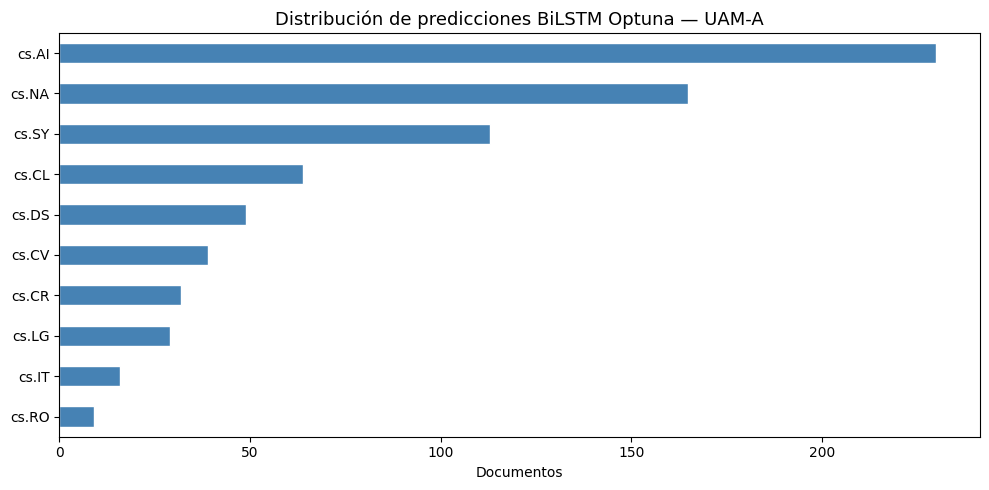

In [31]:
#  Separar por idioma 
df_uam_en = df_uam[df_uam["idioma"] == "en"].reset_index(drop=True)
df_uam_es = df_uam[df_uam["idioma"] != "en"].reset_index(drop=True)

print(f"Documentos en inglés   : {len(df_uam_en):,} → se clasificarán")
print(f"Documentos en español  : {len(df_uam_es):,} → se excluirán de métricas")

#  Tokenización solo sobre documentos en inglés 
print("\nPreparando secuencias UAM-A (inglés) ...")
uam_seqs = [
    text_to_sequence(text)
    for text in tqdm(df_uam_en[UAM_TEXT_COL].fillna(""), desc="  UAM-A tokens")
]

# Dataset y DataLoader de inferencia
uam_ds = ArxivDataset(uam_seqs, [0] * len(uam_seqs))
uam_loader = DataLoader(
    uam_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=(DEVICE.type == "cuda"),
    num_workers=0
)

#  Inferencia 
print("Generando predicciones sobre UAM-A (inglés) ...")
model_optuna.eval()
uam_preds_idx = []

with torch.inference_mode():
    for X_batch, _ in tqdm(uam_loader, desc="  Inferencia"):
        X_batch = X_batch.to(DEVICE, non_blocking=True)
        logits  = model_optuna(X_batch)
        preds   = torch.argmax(logits, dim=1)
        uam_preds_idx.extend(preds.cpu().numpy())

uam_preds_labels = [idx2label[i] for i in uam_preds_idx]
df_uam_en = df_uam_en.copy()
df_uam_en["pred_bilstm"] = uam_preds_labels

print(f"   {len(uam_preds_labels)} predicciones generadas")

#  Marcar no clasificados en df_uam completo 
df_uam["pred_bilstm"] = None
df_uam.loc[df_uam["idioma"] == "en", "pred_bilstm"] = uam_preds_labels

#  Distribución de predicciones 
print("Distribución de predicciones sobre UAM-A (inglés):")
print(pd.Series(uam_preds_labels).value_counts().to_string())

fig, ax = plt.subplots(figsize=(10, 5))
pd.Series(uam_preds_labels).value_counts().sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title("Distribución de predicciones BiLSTM Optuna — UAM-A", fontsize=13)
ax.set_xlabel("Documentos")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}\\bilstm_optuna_uam_distribution_{date_time}.png", dpi=150)
plt.show()